# 03. Potential Outcomes and Counterfactuals

The potential outcomes framework gives causal inference its basic grammar. It lets us say exactly what we mean by the effect of an action, and it makes visible why causal inference is hard.

For one unit, a causal effect compares two possible outcomes:

- the outcome the unit would have under treatment;
- the outcome the same unit would have under control.

The difficulty is that we observe only one of those outcomes. The other is counterfactual: it describes what would have happened under an action that did not occur.

This lecture builds the framework from the ground up using an industry example: a seller-enablement training program. The example is synthetic, so we can inspect the otherwise unobservable potential outcomes and see exactly what goes wrong when we confuse observed comparisons with causal effects.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Define potential outcomes for a binary treatment.
2. Explain why individual causal effects are usually unobserved.
3. State the observed-outcome equation.
4. Distinguish individual treatment effects, ATE, ATT, and ATC.
5. Explain the fundamental problem of causal inference.
6. Show why randomization identifies average causal effects in expectation.
7. Recognize the roles of consistency, no interference, and well-defined treatment versions.


## 1. Why Potential Outcomes?

The previous lectures separated causal questions from descriptive and predictive questions. Potential outcomes make that separation mathematical.

Suppose a business asks:

> What is the effect of enrolling a seller in a training program on their next 30 days of sales margin?

For seller $i$, define two possible outcomes:

$$
Y_i(1) = \text{seller } i \text{'s 30-day margin if trained}
$$

$$
Y_i(0) = \text{seller } i \text{'s 30-day margin if not trained}
$$

The individual causal effect is:

$$
\tau_i = Y_i(1) - Y_i(0)
$$

This definition is simple and profound. It says a causal effect is not a coefficient, not a feature importance score, and not merely an observed difference between two groups. It is a comparison of two possible outcomes for the same unit under two different actions.

Rubin (1974) extended potential-outcomes reasoning to randomized and nonrandomized studies, and Holland (1986) helped popularize the language of the fundamental problem of causal inference. Modern texts and articles often trace the notation back to Neyman's work on randomized experiments, as discussed by Rubin (2008) and Ding (2017).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.precision", 3)


In [2]:
examples = pd.DataFrame(
    [
        {
            "unit": "Seller",
            "treatment": "Enroll in enablement training",
            "control": "No training this month",
            "outcome": "30-day sales margin",
            "potential_outcome_question": "What margin would this seller have under training versus no training?",
        },
        {
            "unit": "Customer",
            "treatment": "Receive retention discount",
            "control": "No discount",
            "outcome": "30-day churn indicator",
            "potential_outcome_question": "Would this same customer churn under discount versus no discount?",
        },
        {
            "unit": "Support ticket",
            "treatment": "LLM-assisted drafting workflow",
            "control": "Human-only workflow",
            "outcome": "Time to resolution",
            "potential_outcome_question": "How long would this ticket take under each workflow?",
        },
        {
            "unit": "Search session",
            "treatment": "New ranking policy",
            "control": "Current ranking policy",
            "outcome": "Contribution margin and refund risk",
            "potential_outcome_question": "What would this session produce under each ranking policy?",
        },
    ]
)

examples


,unit,treatment,control,outcome,potential_outcome_question
0,Seller,Enroll in enablement training,No training this month,30-day sales margin,What margin would this seller have under training versus no training?
1,Customer,Receive retention discount,No discount,30-day churn indicator,Would this same customer churn under discount versus no discount?
2,Support ticket,LLM-assisted drafting workflow,Human-only workflow,Time to resolution,How long would this ticket take under each workflow?
3,Search session,New ranking policy,Current ranking policy,Contribution margin and refund risk,What would this session produce under each ranking policy?


### Discussion

The potential-outcomes notation forces a disciplined habit: define the action and the alternative before estimating anything.

This habit prevents two common mistakes:

1. Treating an observed group difference as a causal effect without asking how units entered the groups.
2. Treating a model input as a manipulable action when it is only a predictor or proxy.

For example, seller tenure may predict margin, but we cannot assign a seller to have had a different past tenure. Training enrollment is an action the business can assign. Causal effects require actions, interventions, or treatment strategies that are meaningful enough to compare.


## 2. The Observed-Outcome Equation

Let $A_i$ be the treatment actually received by unit $i$:

$$
A_i =
\begin{cases}
1 & \text{if unit } i \text{ receives treatment} \\
0 & \text{if unit } i \text{ receives control}
\end{cases}
$$

The observed outcome is:

$$
Y_i = A_iY_i(1) + (1 - A_i)Y_i(0)
$$

This equation says:

- if $A_i = 1$, we observe $Y_i(1)$;
- if $A_i = 0$, we observe $Y_i(0)$.

The missing potential outcome is the counterfactual. If a seller was trained, we do not observe what that same seller's margin would have been without training. If the seller was not trained, we do not observe what that same seller's margin would have been with training.


In [3]:
toy_population = pd.DataFrame(
    {
        "seller_id": ["S01", "S02", "S03", "S04", "S05", "S06"],
        "Y0_no_training": [118, 132, 101, 145, 126, 110],
        "Y1_training": [130, 140, 120, 151, 137, 128],
        "A_training": [1, 0, 1, 0, 0, 1],
    }
)
toy_population["observed_Y"] = np.where(
    toy_population["A_training"] == 1,
    toy_population["Y1_training"],
    toy_population["Y0_no_training"],
)
toy_population["individual_effect_tau"] = (
    toy_population["Y1_training"] - toy_population["Y0_no_training"]
)

toy_population


,seller_id,Y0_no_training,Y1_training,A_training,observed_Y,individual_effect_tau
0,S01,118,130,1,130,12
1,S02,132,140,0,132,8
2,S03,101,120,1,120,19
3,S04,145,151,0,145,6
4,S05,126,137,0,126,11
5,S06,110,128,1,128,18


In [4]:
observed_view = toy_population.assign(
    observed_potential_outcome=np.where(
        toy_population["A_training"] == 1,
        "Y(1) observed",
        "Y(0) observed",
    ),
    missing_counterfactual=np.where(
        toy_population["A_training"] == 1,
        "Y(0) missing",
        "Y(1) missing",
    ),
)[["seller_id", "A_training", "observed_Y", "observed_potential_outcome", "missing_counterfactual"]]

observed_view


,seller_id,A_training,observed_Y,observed_potential_outcome,missing_counterfactual
0,S01,1,130,Y(1) observed,Y(0) missing
1,S02,0,132,Y(0) observed,Y(1) missing
2,S03,1,120,Y(1) observed,Y(0) missing
3,S04,0,145,Y(0) observed,Y(1) missing
4,S05,0,126,Y(0) observed,Y(1) missing
5,S06,1,128,Y(1) observed,Y(0) missing


### Discussion

The first table shows the full science-fiction version: both potential outcomes are visible. The second table shows the real-data version: each seller has one observed outcome and one missing counterfactual.

The individual effect $\tau_i$ is easy to compute in the full table, but not in the real-data table. This is the fundamental challenge. Causal effects are defined using quantities that are only partially observed.


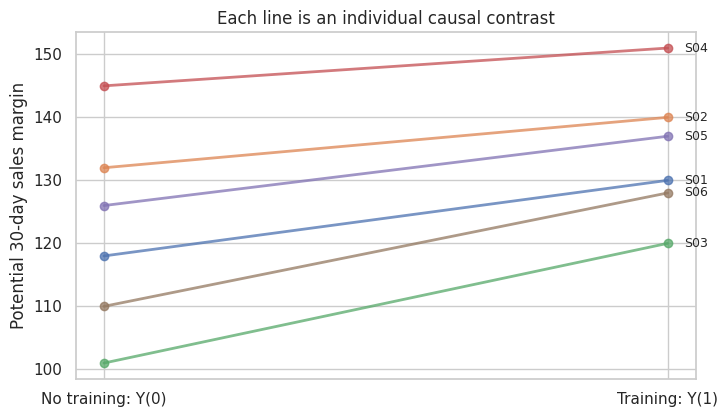

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for _, row in toy_population.iterrows():
    ax.plot(
        [0, 1],
        [row["Y0_no_training"], row["Y1_training"]],
        marker="o",
        linewidth=2,
        alpha=0.75,
    )
    ax.text(1.03, row["Y1_training"], row["seller_id"], va="center", fontsize=9)

ax.set_xticks([0, 1], ["No training: Y(0)", "Training: Y(1)"])
ax.set_ylabel("Potential 30-day sales margin")
ax.set_title("Each line is an individual causal contrast")
plt.show()


### Discussion of the Plot

Each line connects a seller's outcome under no training to the same seller's outcome under training. The slope of the line is the individual treatment effect.

This plot is conceptually useful, but it is not a plot we can make from ordinary observational data. In real data, we would see only one endpoint of each line. The other endpoint is counterfactual.


## 3. The Fundamental Problem of Causal Inference

The individual causal effect is:

$$
\tau_i = Y_i(1) - Y_i(0)
$$

But for any unit $i$, we observe either $Y_i(1)$ or $Y_i(0)$, not both. Holland (1986) called this the fundamental problem of causal inference.

This does not mean causal inference is impossible. It means we usually shift from individual effects to average effects, and we rely on a design or assumptions to learn about the missing counterfactual outcomes.

The central move is:

> We cannot observe both potential outcomes for the same unit, so we try to construct a credible comparison group whose observed outcomes stand in for the missing counterfactuals.


In [6]:
true_toy_ate = toy_population["individual_effect_tau"].mean()
observed_group_difference = (
    toy_population.loc[toy_population["A_training"] == 1, "observed_Y"].mean()
    - toy_population.loc[toy_population["A_training"] == 0, "observed_Y"].mean()
)

pd.DataFrame(
    {
        "quantity": [
            "True average treatment effect using both potential outcomes",
            "Observed treated-minus-control difference",
        ],
        "value": [true_toy_ate, observed_group_difference],
    }
)


,quantity,value
0,True average treatment effect using both potential outcomes,12.333
1,Observed treated-minus-control difference,-8.333


### Discussion

In this tiny example, the true average effect and the observed group difference are not the same. The observed comparison depends on which sellers happened to be trained and which sellers happened to be untreated.

If training is assigned randomly, the observed control group can be a credible stand-in for the treated group's missing $Y(0)$ outcomes, at least on average over repeated random assignments. If training is assigned to sellers with different baseline potential outcomes, the observed comparison can be biased.


## 4. A Larger Seller-Training Simulation

Now we will create a more realistic synthetic dataset.

The business runs a seller training program. Sellers with greater training need are more likely to be assigned to training. The training tends to help, especially for sellers who need it. But high-need sellers also have lower baseline margin without training.

This setup creates a common industry pattern:

- the intervention is useful;
- the treated group still looks worse in observed outcomes because they started from a worse baseline.


In [7]:
rng = np.random.default_rng(123)
n_sellers = 600

seller_quality = rng.normal(loc=0, scale=1, size=n_sellers)
training_need = np.clip(
    rng.normal(loc=0, scale=1, size=n_sellers) - 0.8 * seller_quality,
    -2.5,
    2.5,
)

# Potential outcome under no training.
y0_no_training = (
    120
    + 25 * seller_quality
    - 16 * training_need
    + rng.normal(loc=0, scale=8, size=n_sellers)
)

# Heterogeneous treatment effect: training helps high-need sellers more.
true_tau = 10 + 9 * np.maximum(training_need, 0) + 3 * rng.normal(loc=0, scale=1, size=n_sellers)
true_tau = np.clip(true_tau, 2, 34)
y1_training = y0_no_training + true_tau

# Historical assignment: high-need and lower-quality sellers are more likely to receive training.
training_probability = 1 / (1 + np.exp(-(-0.2 + 1.1 * training_need - 0.55 * seller_quality)))
training = rng.binomial(n=1, p=training_probability)

observed_margin = np.where(training == 1, y1_training, y0_no_training)

sellers = pd.DataFrame(
    {
        "seller_quality": seller_quality,
        "training_need": training_need,
        "training_probability": training_probability,
        "training": training,
        "sales_margin_30d": observed_margin,
        # Simulation-only columns.
        "_Y0_no_training": y0_no_training,
        "_Y1_training": y1_training,
        "_tau": true_tau,
    }
)

sellers.head()


,seller_quality,training_need,training_probability,training,sales_margin_30d,_Y0_no_training,_Y1_training,_tau
0,-0.989,-1.546,0.205,0,123.323,123.323,133.406,10.083
1,-0.368,1.103,0.771,1,108.449,89.781,108.449,18.668
2,1.288,0.203,0.335,0,163.826,163.826,177.403,13.578
3,0.194,1.723,0.830,1,121.237,94.140,121.237,27.097
4,0.920,-0.830,0.165,0,147.801,147.801,156.918,9.117


In [8]:
true_ate = sellers["_tau"].mean()
observed_difference = (
    sellers.loc[sellers["training"] == 1, "sales_margin_30d"].mean()
    - sellers.loc[sellers["training"] == 0, "sales_margin_30d"].mean()
)

summary = pd.DataFrame(
    {
        "quantity": [
            "Training rate",
            "True ATE: E[Y(1) - Y(0)]",
            "Observed difference: trained minus not trained",
        ],
        "value": [
            sellers["training"].mean(),
            true_ate,
            observed_difference,
        ],
    }
)

summary


,quantity,value
0,Training rate,0.470
1,True ATE: E[Y(1) - Y(0)],14.432
2,Observed difference: trained minus not trained,-26.632


In [9]:
group_summary = (
    sellers.groupby("training")
    .agg(
        n=("sales_margin_30d", "size"),
        observed_margin=("sales_margin_30d", "mean"),
        mean_quality=("seller_quality", "mean"),
        mean_training_need=("training_need", "mean"),
        mean_Y0=("_Y0_no_training", "mean"),
        mean_Y1=("_Y1_training", "mean"),
        mean_tau=("_tau", "mean"),
    )
    .rename(index={0: "Not trained", 1: "Trained"})
)

group_summary


,n,observed_margin,mean_quality,mean_training_need,mean_Y0,mean_Y1,mean_tau
training,,,,,,,
Not trained,318,141.068,0.430,-0.623,141.068,152.634,11.566
Trained,282,114.435,-0.459,0.730,96.771,114.435,17.664


### Discussion

The true ATE is positive: training improves 30-day margin on average.

The observed treated-minus-control difference is negative. That does not mean training harmed sellers. It means the training program was targeted toward sellers with lower baseline potential outcomes. The trained sellers had more need and lower expected margin without training.

Potential outcomes let us say this precisely:

- the causal effect compares $Y_i(1)$ and $Y_i(0)$ for the same seller;
- the observed difference compares $Y_i$ for different sellers selected into different treatment states.

The observed difference is a mixture of treatment effects and baseline differences.


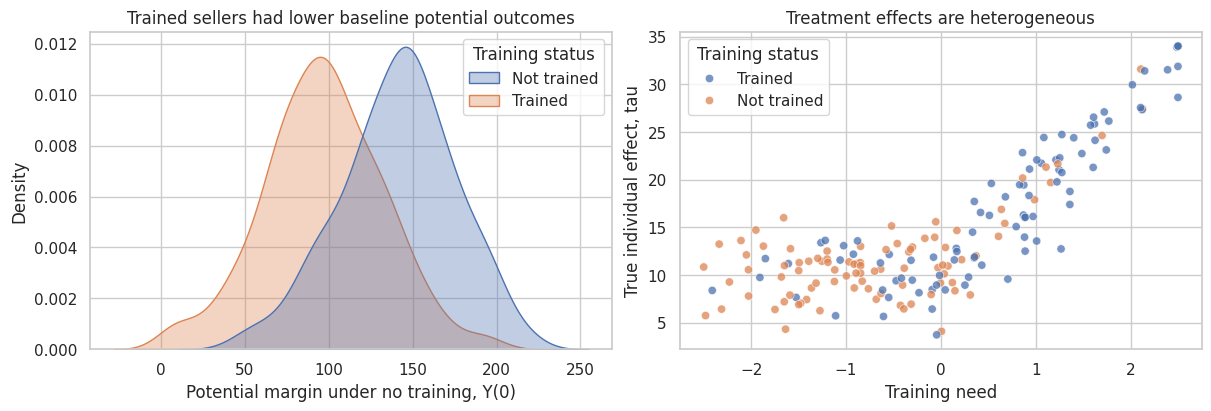

In [10]:
plot_data = sellers.copy()
plot_data["Training status"] = plot_data["training"].map({0: "Not trained", 1: "Trained"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sns.kdeplot(
    data=plot_data,
    x="_Y0_no_training",
    hue="Training status",
    common_norm=False,
    fill=True,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Trained sellers had lower baseline potential outcomes")
axes[0].set_xlabel("Potential margin under no training, Y(0)")

sns.scatterplot(
    data=plot_data.sample(180, random_state=4),
    x="training_need",
    y="_tau",
    hue="Training status",
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("Treatment effects are heterogeneous")
axes[1].set_xlabel("Training need")
axes[1].set_ylabel("True individual effect, tau")

plt.show()


### Discussion of the Plot

The left panel shows selection into treatment. Sellers who were trained tend to have lower $Y(0)$ values: they would have performed worse without training.

The right panel shows treatment-effect heterogeneity. Training helps some sellers more than others, especially those with greater training need. This matters because there are many possible causal estimands. We may care about the average effect for everyone, the average effect among trained sellers, or the effect for high-need sellers.


## 5. ATE, ATT, and ATC

Three common average causal effects are:

$$
ATE = E[Y(1) - Y(0)]
$$

$$
ATT = E[Y(1) - Y(0) \mid A = 1]
$$

$$
ATC = E[Y(1) - Y(0) \mid A = 0]
$$

The ATE asks about the full target population. The ATT asks about units who actually received treatment. The ATC asks about units who actually did not receive treatment.

These are different questions. In industry, choosing the estimand depends on the decision:

- ATE: should we make the training program broadly available?
- ATT: how much did the program help sellers who were actually trained?
- ATC: what might happen if we expand training to sellers who were not trained?


In [11]:
effects = pd.DataFrame(
    {
        "estimand": ["ATE", "ATT", "ATC"],
        "definition": [
            "Average effect over all sellers",
            "Average effect among trained sellers",
            "Average effect among not-trained sellers",
        ],
        "true_value_in_simulation": [
            sellers["_tau"].mean(),
            sellers.loc[sellers["training"] == 1, "_tau"].mean(),
            sellers.loc[sellers["training"] == 0, "_tau"].mean(),
        ],
    }
)

effects


,estimand,definition,true_value_in_simulation
0,ATE,Average effect over all sellers,14.432
1,ATT,Average effect among trained sellers,17.664
2,ATC,Average effect among not-trained sellers,11.566


### Discussion

The ATT is larger than the ATC in this simulation because training was targeted toward sellers with greater need, and those sellers benefit more.

This is not a statistical technicality. It changes the business interpretation. If the trained sellers are exactly the sellers most likely to benefit, the effect among current participants may overstate the effect of expanding the program to all sellers. If expansion reaches lower-need sellers, the incremental value may be smaller.


## 6. Randomization Reveals Average Effects in Expectation

Randomization does not reveal both potential outcomes for any one seller. The fundamental problem remains at the individual level.

What randomization does is make the treated and control groups comparable before treatment, on average over repeated random assignments. With random assignment, the control group's observed outcomes estimate what the treated group would have experienced under control, and vice versa.

For a completely randomized experiment, a simple estimator is:

$$
\hat{\tau}_{diff} = \bar{Y}_{A=1} - \bar{Y}_{A=0}
$$

Under random assignment, this estimator is centered on the finite-population ATE across repeated randomizations.


In [12]:
rng_random = np.random.default_rng(2026)
n_simulations = 4_000
randomization_estimates = []

for _ in range(n_simulations):
    randomized_training = rng_random.binomial(n=1, p=0.5, size=n_sellers)
    randomized_outcome = np.where(
        randomized_training == 1,
        sellers["_Y1_training"],
        sellers["_Y0_no_training"],
    )
    estimate = (
        randomized_outcome[randomized_training == 1].mean()
        - randomized_outcome[randomized_training == 0].mean()
    )
    randomization_estimates.append(estimate)

randomization_estimates = np.array(randomization_estimates)

pd.DataFrame(
    {
        "quantity": [
            "True finite-population ATE",
            "Mean randomized difference-in-means over simulations",
            "Standard deviation over randomizations",
            "2.5th percentile",
            "97.5th percentile",
        ],
        "value": [
            true_ate,
            randomization_estimates.mean(),
            randomization_estimates.std(),
            np.percentile(randomization_estimates, 2.5),
            np.percentile(randomization_estimates, 97.5),
        ],
    }
)


,quantity,value
0,True finite-population ATE,14.432
1,Mean randomized difference-in-means over simulations,14.534
2,Standard deviation over randomizations,3.236
3,2.5th percentile,8.079
4,97.5th percentile,20.758


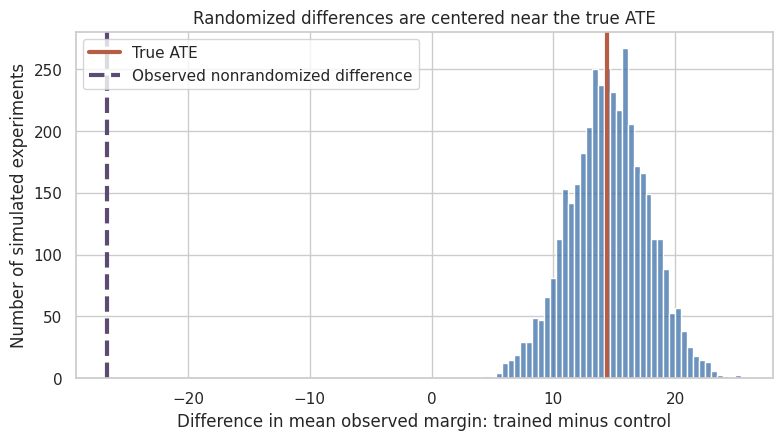

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(randomization_estimates, bins=45, color="#3b6ea8", alpha=0.75, ax=ax)
ax.axvline(true_ate, color="#b75d45", linewidth=3, label="True ATE")
ax.axvline(observed_difference, color="#5c4a72", linewidth=3, linestyle="--", label="Observed nonrandomized difference")
ax.set_title("Randomized differences are centered near the true ATE")
ax.set_xlabel("Difference in mean observed margin: trained minus control")
ax.set_ylabel("Number of simulated experiments")
ax.legend()
plt.show()


### Discussion

The histogram shows what would happen if we repeatedly randomized the same finite population of sellers. The center of the distribution is close to the true ATE.

The dashed line shows the original nonrandomized observed difference. It is far from the true ATE because training was targeted toward sellers with worse baseline potential outcomes.

This illustrates why design matters. The estimator `treated mean - control mean` can be excellent under random assignment and badly misleading under targeted assignment. The formula did not change. The assignment mechanism changed.


## 7. Consistency, SUTVA, and Well-Defined Treatments

Potential outcomes are useful only when the treatment is well enough defined. Three ideas appear constantly.

**Consistency** says the observed outcome equals the potential outcome under the treatment actually received:

$$
Y_i = Y_i(A_i)
$$

If seller $i$ receives training, then the observed outcome is $Y_i(1)$. If seller $i$ does not receive training, then the observed outcome is $Y_i(0)$.

**No interference** says one unit's potential outcome does not depend on other units' treatment assignments. In binary-treatment notation, seller $i$'s potential outcome depends on $A_i$, not on every other seller's assignment.

**No hidden versions of treatment** says the treatment label corresponds to a sufficiently specific intervention. If "training" includes a two-hour webinar for some sellers, a six-week coaching program for others, and an AI recommendation tool for others, then $Y_i(1)$ may not be well defined.

These ideas are often grouped under the stable unit treatment value assumption, or SUTVA. Schwartz, Gatto, and Campbell (2012) discuss SUTVA as involving no interference and no compound treatment versions; marketplace experimentation work also highlights how interference can arise when budgets or competition connect units.


In [14]:
sutva_examples = pd.DataFrame(
    [
        {
            "issue": "Consistency problem",
            "example": "The data says training=1, but some sellers never attended the assigned session.",
            "why_it_matters": "The observed outcome may not match the intended treatment version.",
        },
        {
            "issue": "Hidden versions of treatment",
            "example": "Training=1 mixes self-paced videos, live coaching, and AI-guided recommendations.",
            "why_it_matters": "There may be multiple Y(1) outcomes, one for each treatment version.",
        },
        {
            "issue": "Interference",
            "example": "Training some sellers changes marketplace competition or shared ad budgets for other sellers.",
            "why_it_matters": "One seller's outcome may depend on other sellers' treatment assignments.",
        },
        {
            "issue": "Timing ambiguity",
            "example": "Some sellers begin training before the measurement window, others halfway through it.",
            "why_it_matters": "The treatment strategy and time zero are not aligned.",
        },
    ]
)

sutva_examples


,issue,example,why_it_matters
0,Consistency problem,"The data says training=1, but some sellers never attended the assigned session.",The observed outcome may not match the intended treatment version.
1,Hidden versions of treatment,"Training=1 mixes self-paced videos, live coaching, and AI-guided recommendations.","There may be multiple Y(1) outcomes, one for each treatment version."
2,Interference,Training some sellers changes marketplace competition or shared ad budgets for other sellers.,One seller's outcome may depend on other sellers' treatment assignments.
3,Timing ambiguity,"Some sellers begin training before the measurement window, others halfway through it.",The treatment strategy and time zero are not aligned.


### Discussion

These assumptions can sound abstract, but they are operational questions.

Before estimating the effect of a program, ask:

- What exactly counts as treatment?
- When does treatment start?
- Is control truly no treatment, delayed treatment, business as usual, or another active intervention?
- Can treated units affect untreated units?
- Are there capacity constraints, budget constraints, ranking competition, or social spillovers?

If the answers are unclear, the potential outcomes are unclear too.


## 8. Counterfactual Thinking in Applied Work

Potential outcomes do not require mystical thinking. A counterfactual is simply the missing outcome under a well-defined alternative action.

In applied work, counterfactual thinking shows up as practical questions:

- If this trained seller had not been trained, what would their margin have been?
- If this customer had not received a discount, would they have churned?
- If this support ticket had gone through the old workflow, how long would resolution have taken?
- If this product had stayed lower in the ranking, would the session have generated less margin?

The hard part is not writing $Y_i(1)$ and $Y_i(0)$. The hard part is defending why the data we observe can teach us about the missing potential outcomes.


In [15]:
workflow = pd.DataFrame(
    [
        (1, "Define the unit", "Seller, customer, ticket, session, store, market, or user."),
        (2, "Define treatment and control", "Make both actions operational and time-stamped."),
        (3, "Define potential outcomes", "State Y(1), Y(0), and the outcome measurement window."),
        (4, "Choose the estimand", "ATE, ATT, ATC, subgroup effect, or policy value."),
        (5, "Understand assignment", "Randomized, targeted, threshold-based, self-selected, or historical policy."),
        (6, "Defend identification", "Explain why observed outcomes can stand in for missing counterfactuals."),
        (7, "Estimate and communicate", "Report estimates, uncertainty, assumptions, limitations, and decision implications."),
    ],
    columns=["step", "task", "applied_question"],
)

workflow


,step,task,applied_question
0,1,Define the unit,"Seller, customer, ticket, session, store, market, or user."
1,2,Define treatment and control,Make both actions operational and time-stamped.
2,3,Define potential outcomes,"State Y(1), Y(0), and the outcome measurement window."
3,4,Choose the estimand,"ATE, ATT, ATC, subgroup effect, or policy value."
4,5,Understand assignment,"Randomized, targeted, threshold-based, self-selected, or historical policy."
5,6,Defend identification,Explain why observed outcomes can stand in for missing counterfactuals.
6,7,Estimate and communicate,"Report estimates, uncertainty, assumptions, limitations, and decision implications."


## 9. Key Takeaways

1. Potential outcomes define causal effects as comparisons between outcomes under alternative actions for the same unit.
2. For binary treatment, each unit has $Y_i(1)$ and $Y_i(0)$, but we observe only one of them.
3. The observed-outcome equation is $Y_i = A_iY_i(1) + (1 - A_i)Y_i(0)$.
4. The individual causal effect $\tau_i = Y_i(1) - Y_i(0)$ is usually unobserved.
5. Average effects such as ATE, ATT, and ATC answer different decision questions.
6. Randomization makes treated and control groups comparable on average, so simple differences in means can estimate the ATE.
7. In observational data, the assignment process determines whether observed comparisons can stand in for missing counterfactuals.
8. Consistency, no interference, and well-defined treatment versions are not technical footnotes; they determine whether the causal question is coherent.

## Preview of the Next Lecture

The next lecture introduces the components of a causal estimand more explicitly: treatment, outcome, estimand, and target population. We will connect the potential-outcomes notation to business-ready question formulation.


## References

- Ding, P. (2017). A paradox from randomization-based causal inference. *Statistical Science, 32*(3), 331-345. https://doi.org/10.1214/16-STS571. Access: open / DOI page.
- Holland, P. W. (1986). Statistics and causal inference. *Journal of the American Statistical Association, 81*(396), 945-960. https://doi.org/10.1080/01621459.1986.10478354. Access: publisher / DOI page.
- Li, X., Ding, P., & Lin, Q. (2019). Randomization inference for peer effects. *Journal of the American Statistical Association, 114*(528), 1651-1664. https://doi.org/10.1080/01621459.2018.1512863. Access: open / DOI page.
- Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology, 66*(5), 688-701. https://doi.org/10.1037/h0037350. Access: publisher / DOI page.
- Rubin, D. B. (2008). For objective causal inference, design trumps analysis. *The Annals of Applied Statistics, 2*(3), 808-840. https://doi.org/10.1214/08-AOAS187. Access: open / DOI page.
- Schwartz, S., Gatto, N. M., & Campbell, U. B. (2012). Extending the sufficient component cause model to describe the Stable Unit Treatment Value Assumption (SUTVA). *Epidemiologic Perspectives & Innovations, 9*, 3. https://doi.org/10.1186/1742-5573-9-3. Access: open / DOI page.
